In [23]:
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [10]:
# Download latest version
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")
import pandas as pd
import os

file_path = os.path.join(path, "household_power_consumption.txt")

df = pd.read_csv(
    file_path,
    sep=';',
    parse_dates={'dt':['Date','Time']},
    infer_datetime_format=True,
    low_memory=False,
    na_values=['nan', '?'],
    index_col='dt'
)
df.head()

C:\Users\15302\AppData\Local\Temp\ipykernel_38424\1776949478.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\15302\AppData\Local\Temp\ipykernel_38424\1776949478.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [11]:
df = df.apply(pd.to_numeric, errors='coerce')

### Handling Missing Values in the Dataset

In [12]:
df = df.interpolate(method='time')
df = df.fillna(method='ffill')
df.isna().sum()

C:\Users\15302\AppData\Local\Temp\ipykernel_38424\1817038184.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

### Visulaize Dataset 

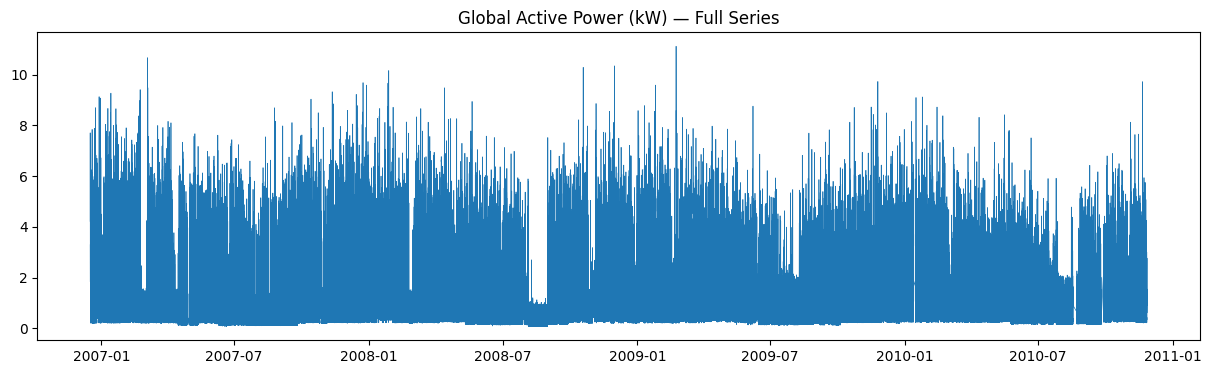

In [13]:
plt.figure(figsize=(15,4))
plt.plot(df['Global_active_power'], linewidth=0.5)
plt.title("Global Active Power (kW) — Full Series")
plt.show()


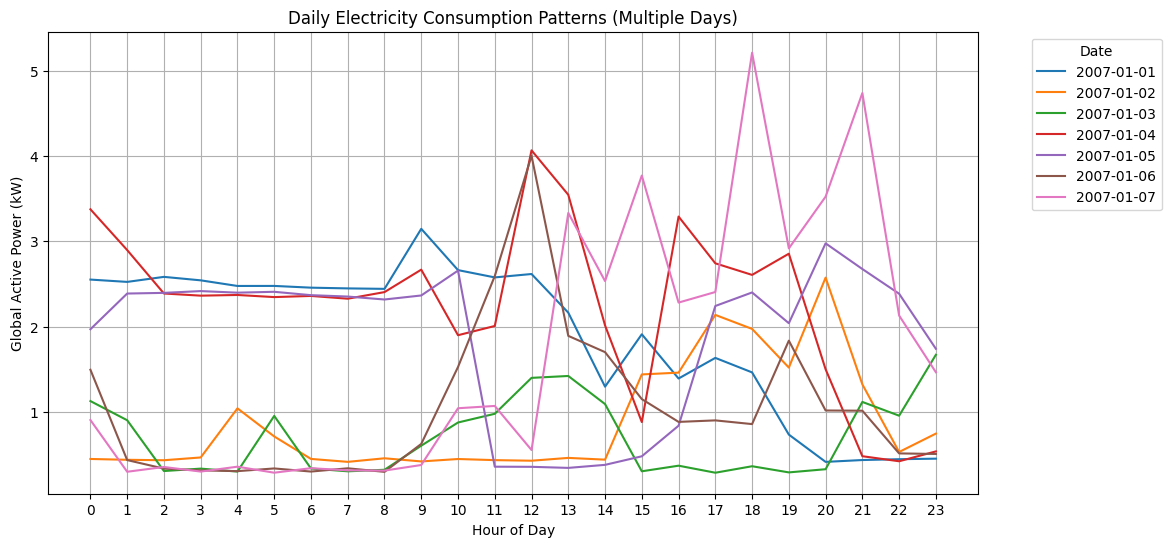

In [14]:

# Select a small range of days to compare (change to any week)
sample_days = df['2007-01-01':'2007-01-07']  # 7 days

# Pivot so each day becomes a separate line with index = hour
daily_matrix = sample_days['Global_active_power'].groupby(
    [sample_days.index.date, sample_days.index.hour]
).mean().unstack(level=0)

plt.figure(figsize=(12,6))

# Plot each day’s curve (24 hours)
for col in daily_matrix.columns:
    plt.plot(daily_matrix.index, daily_matrix[col], label=str(col))

plt.title("Daily Electricity Consumption Patterns (Multiple Days)")
plt.xlabel("Hour of Day")
plt.ylabel("Global Active Power (kW)")
plt.xticks(range(24))
plt.grid(True)
plt.legend(title="Date", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()



In [15]:
df['hour'] = df.index.hour
df['day'] = df.index.date

daily_matrix = df.pivot_table(
    index='hour',
    columns='day',
    values='Global_active_power',
    aggfunc='mean'
)
# Keep only days with 24 valid hourly values
daily_matrix = daily_matrix.dropna(axis=1)  # drop columns (days) with any NaN


In [16]:


# Each row = a day, each column = hour 0–23
X = daily_matrix.T  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [26]:

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)


In [27]:
cluster_map = dict(zip(X.index, cluster_labels))


In [28]:
clustered_days = pd.DataFrame({
    'day': X.index,
    'cluster': cluster_labels
}).set_index('day')

daily_with_cluster = daily_matrix.T.join(clustered_days)

centroids = daily_with_cluster.groupby('cluster').mean().T  # 24 × cluster count
centroids


cluster,0,1,2
0,0.624992,0.540150,2.158421
1,0.486909,0.443039,2.008843
2,0.436191,0.390918,1.832843
3,0.396546,0.374015,1.665404
4,0.406780,0.376463,1.530995
5,0.420149,0.389126,1.481008
6,0.828759,0.678974,1.547753
7,1.730370,1.234183,1.805408
8,1.724285,1.165270,1.728129
9,1.573996,1.043547,1.749775


#### cluster 1: low consumption days
#### cluster 0: medium consumption days
#### cluser 2: high consumption days

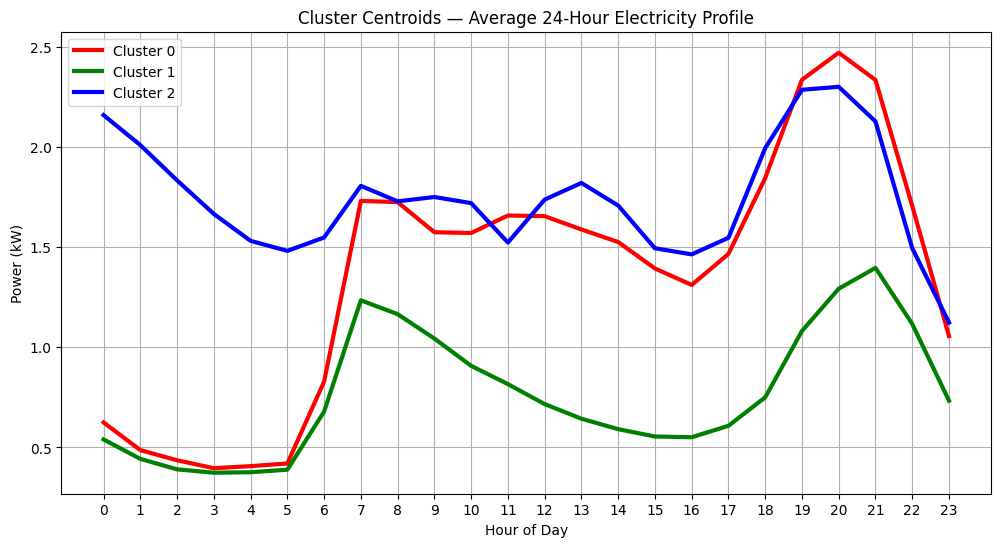

In [29]:

plt.figure(figsize=(12,6))

colors = ['red', 'green', 'blue']

for c in centroids.columns:
    plt.plot(
        centroids.index,  # hour 0–23
        centroids[c],
        linewidth=3,
        color=colors[c],
        label=f'Cluster {c}'
    )

plt.title("Cluster Centroids — Average 24-Hour Electricity Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.show()


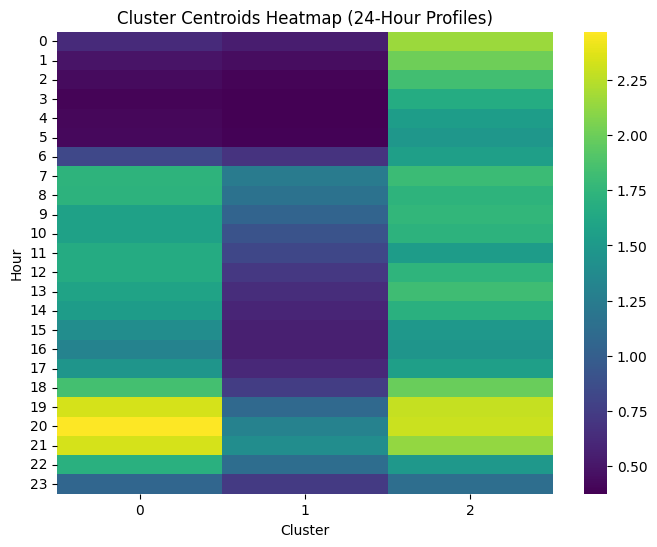

In [30]:

plt.figure(figsize=(8,6))
sns.heatmap(
    centroids,      # 24 rows × k clusters
    cmap='viridis',
    annot=False
)
plt.title("Cluster Centroids Heatmap (24-Hour Profiles)")
plt.xlabel("Cluster")
plt.ylabel("Hour")
plt.yticks(rotation=0)
plt.show()


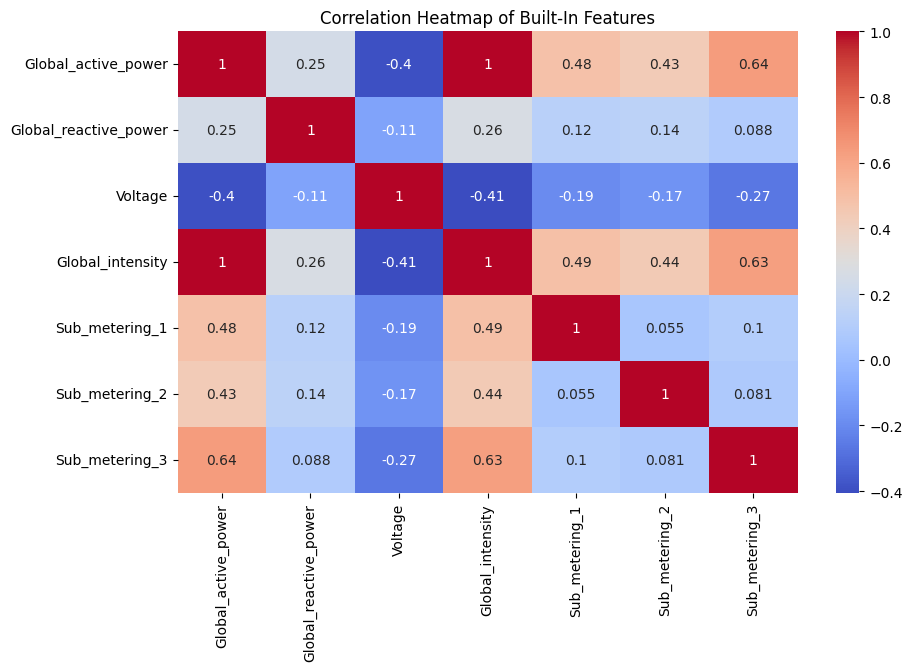

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Global_active_power','Global_reactive_power','Voltage',
                'Global_intensity','Sub_metering_1','Sub_metering_2',
                'Sub_metering_3']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Built-In Features")
plt.show()


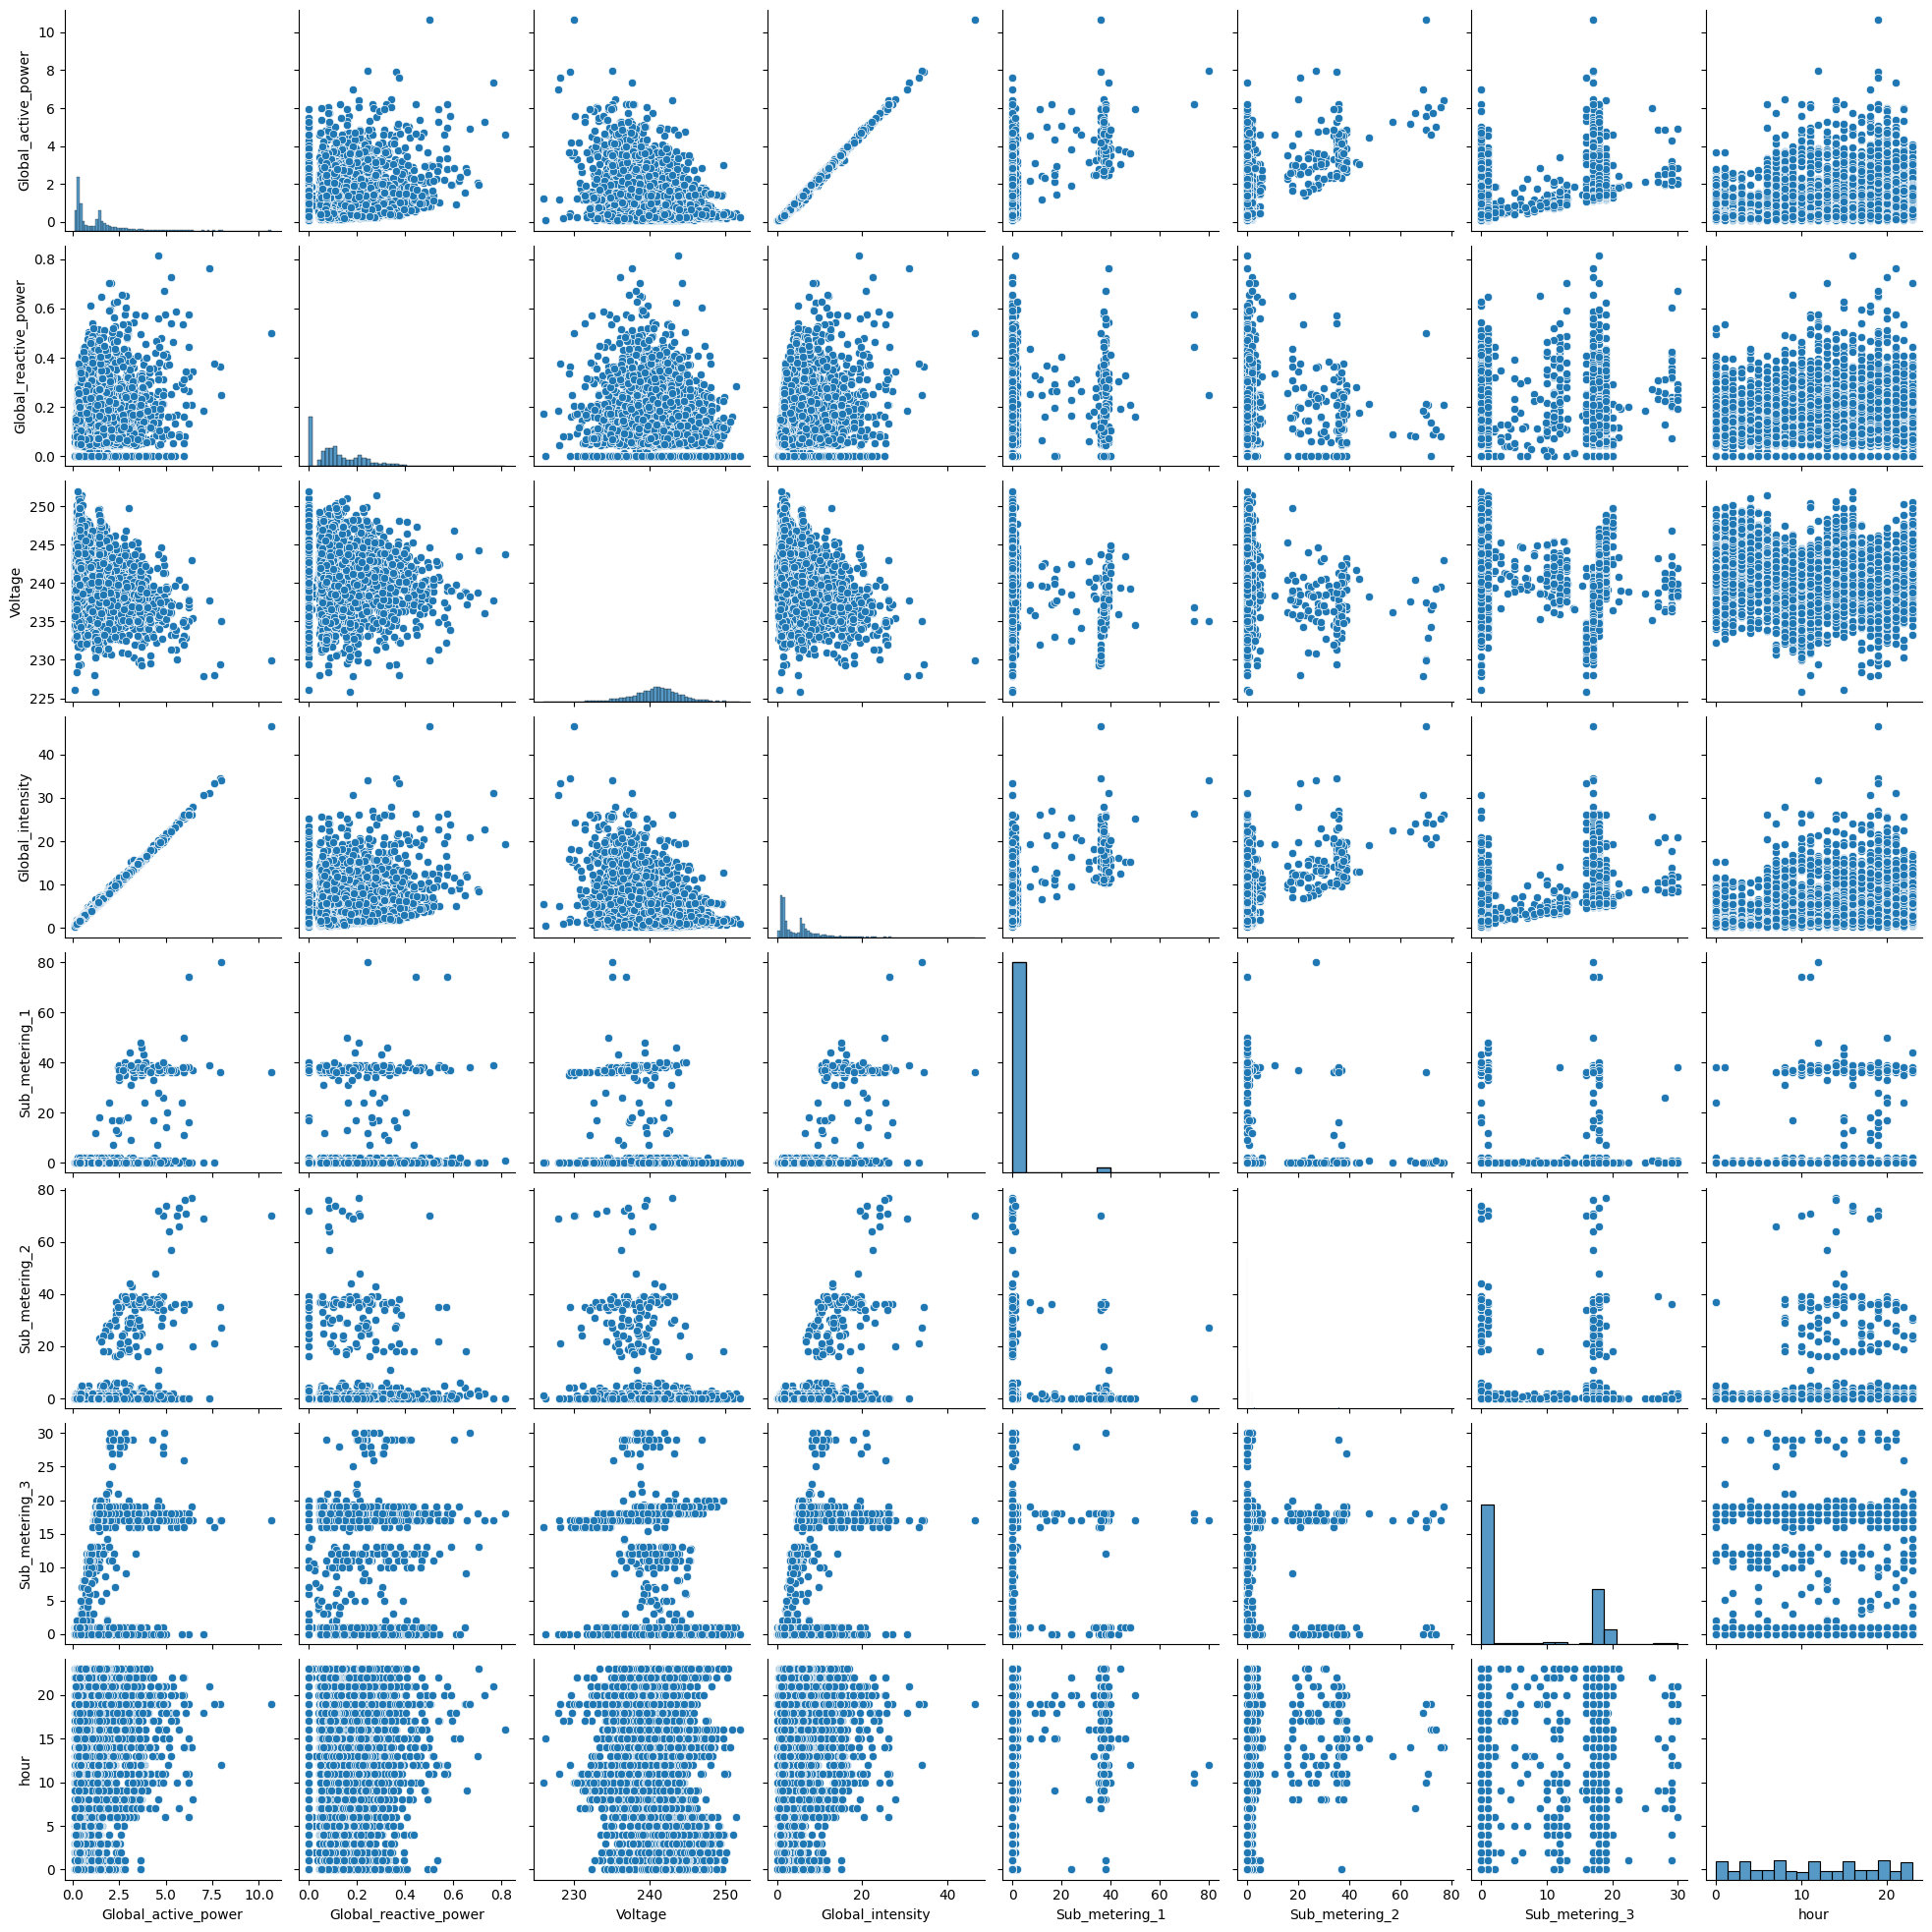

In [31]:
sample_df = df.sample(5000) 
sns.pairplot(sample_df)
plt.show()


In [ ]:

# 1. LAG FEATURES

df['lag_1']   = df['Global_active_power'].shift(1)
df['lag_24']  = df['Global_active_power'].shift(24)
df['lag_48']  = df['Global_active_power'].shift(48)

# 2. ROLLING FEATURES
df['roll_3']   = df['Global_active_power'].rolling(3).mean()
df['roll_24']  = df['Global_active_power'].rolling(24).mean()
df['roll_168'] = df['Global_active_power'].rolling(168).mean()  # 7 days

# 3. TIME FEATURES
df['hour']       = df.index.hour
df['weekday']    = df.index.weekday
df['month']      = df.index.month
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# 4. CYCLIC ENCODING
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


# 5. SUB-METERING FEATURES
df['sub_total'] = (
    df['Sub_metering_1'] +
    df['Sub_metering_2'] +
    df['Sub_metering_3']
)

# Avoid division by zero
df['sub_total'] = df['sub_total'].replace(0, np.nan)

df['sub_ratio_1'] = df['Sub_metering_1'] / df['sub_total']
df['sub_ratio_2'] = df['Sub_metering_2'] / df['sub_total']
df['sub_ratio_3'] = df['Sub_metering_3'] / df['sub_total']

df[['sub_ratio_1','sub_ratio_2','sub_ratio_3']] = \
df[['sub_ratio_1','sub_ratio_2','sub_ratio_3']].fillna(0)

# 6. TARGET VARIABLE
df['target'] = df['Global_active_power'].shift(-1)


# REMOVE NaNs (from lag/roll/target)

df = df.dropna()

# 8. SELECT FEATURES

feature_cols = [
    'lag_1','lag_24','lag_48',
    'roll_3','roll_24','roll_168',
    'hour','weekday','month','is_weekend',
    'hour_sin','hour_cos',
    'Global_reactive_power',
    'Voltage','Global_intensity',
    'sub_total','sub_ratio_1','sub_ratio_2','sub_ratio_3'
]

X = df[feature_cols]
y = df['target']

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)


C:\Users\15302\AppData\Local\Temp\ipykernel_38424\997396611.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lag_1']   = df['Global_active_power'].shift(1)
C:\Users\15302\AppData\Local\Temp\ipykernel_38424\997396611.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lag_24']  = df['Global_active_power'].shift(24)
C:\Users\15302\AppData\Local\Temp\ipykernel_38424\997396611.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

Final X shape: (1475974, 19)
Final y shape: (1475974,)


In [36]:
n = len(df)

train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)



In [37]:
WINDOW = 24

def create_sequences(X, y, window):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, WINDOW)
X_val_seq,   y_val_seq   = create_sequences(X_val_scaled,   y_val.values,   WINDOW)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test.values,  WINDOW)


In [ ]:
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
# Download latest version
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")
import pandas as pd
import os

file_path = os.path.join(path, "household_power_consumption.txt")

df = pd.read_csv(
    file_path,
    sep=';',
    parse_dates={'dt':['Date','Time']},
    infer_datetime_format=True,
    low_memory=False,
    na_values=['nan', '?'],
    index_col='dt'
)
df.head()

C:\Users\15302\AppData\Local\Temp\ipykernel_50984\1776949478.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\15302\AppData\Local\Temp\ipykernel_50984\1776949478.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')

### Handling Missing Values in the Dataset

In [ ]:
df = df.interpolate(method='time')
df = df.fillna(method='ffill')
df.isna().sum()

C:\Users\15302\AppData\Local\Temp\ipykernel_50984\1817038184.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

### Visulaize Dataset 

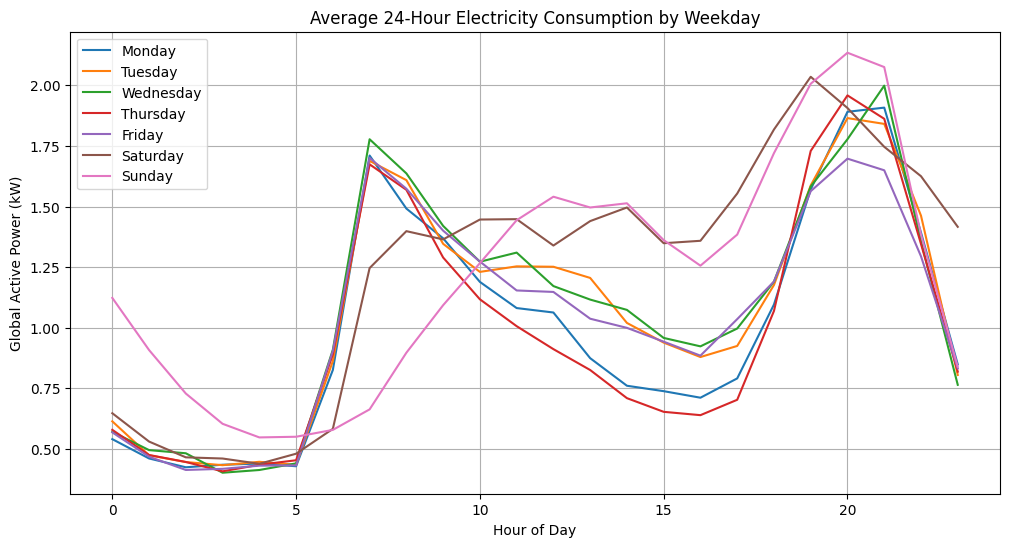

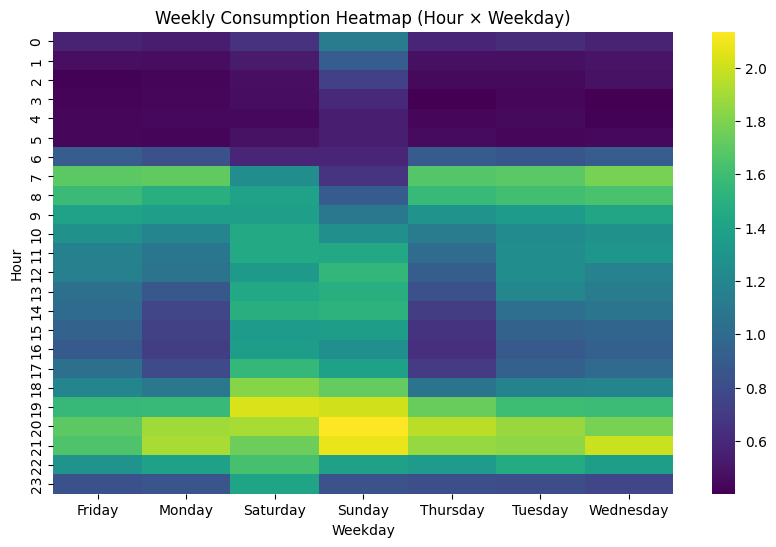

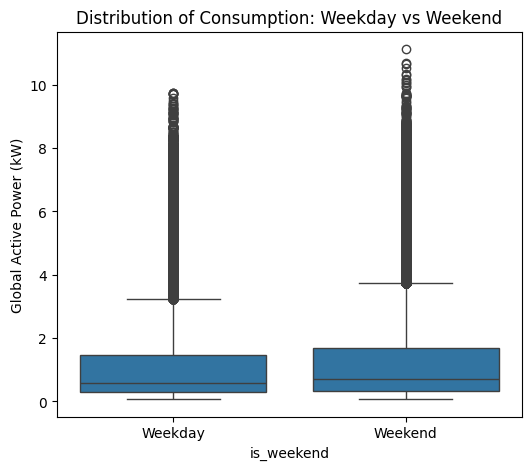

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = df.copy()

# Convert numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df = df.dropna(subset=['Global_active_power'])

# Extract weekday/hour
df['weekday'] = df.index.weekday        # 0=Mon ... 6=Sun
df['hour'] = df.index.hour

# --------------------------
# 1. Compute Weekly Profile
# --------------------------
weekly_profile = (
    df.groupby(['weekday', 'hour'])['Global_active_power']
    .mean()
    .reset_index()
)

# Add weekday names AFTER grouping
weekday_map = {
    0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday',
    4:'Friday', 5:'Saturday', 6:'Sunday'
}
weekly_profile['weekday_name'] = weekly_profile['weekday'].map(weekday_map)

# --------------------------
# 1. Line Plot (24h curve)
# --------------------------
plt.figure(figsize=(12,6))
for w in range(7):
    sub = weekly_profile[weekly_profile['weekday'] == w]
    plt.plot(sub['hour'], sub['Global_active_power'], label=weekday_map[w])

plt.title("Average 24-Hour Electricity Consumption by Weekday")
plt.xlabel("Hour of Day")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 2. Weekly Heatmap
# --------------------------
heatmap_data = weekly_profile.pivot(index='hour', columns='weekday_name',
                                    values='Global_active_power')

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Weekly Consumption Heatmap (Hour × Weekday)")
plt.xlabel("Weekday")
plt.ylabel("Hour")
plt.show()

# --------------------------
# 3. Weekday vs Weekend Boxplot
# --------------------------
df['is_weekend'] = df['weekday'] >= 5

plt.figure(figsize=(6,5))
sns.boxplot(x=df['is_weekend'], y=df['Global_active_power'])
plt.xticks([0,1], ["Weekday", "Weekend"])
plt.title("Distribution of Consumption: Weekday vs Weekend")
plt.ylabel("Global Active Power (kW)")
plt.show()


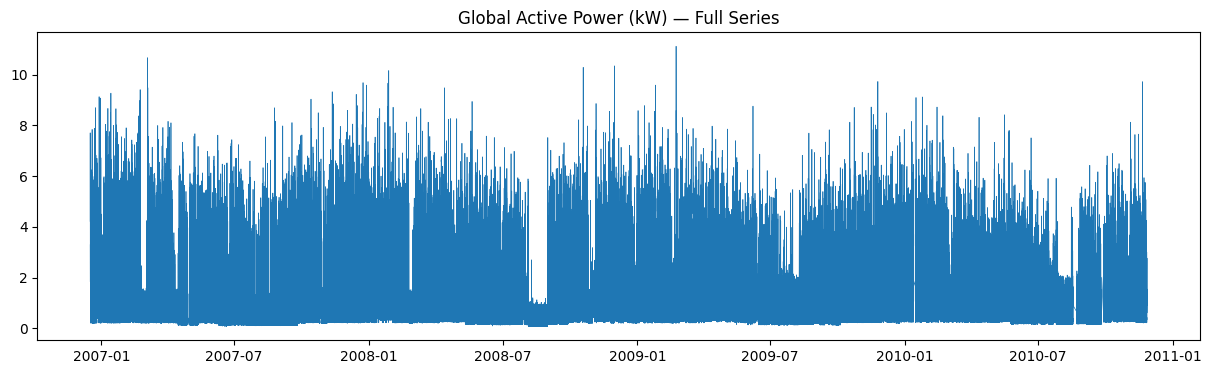

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(df['Global_active_power'], linewidth=0.5)
plt.title("Global Active Power (kW) — Full Series")
plt.show()


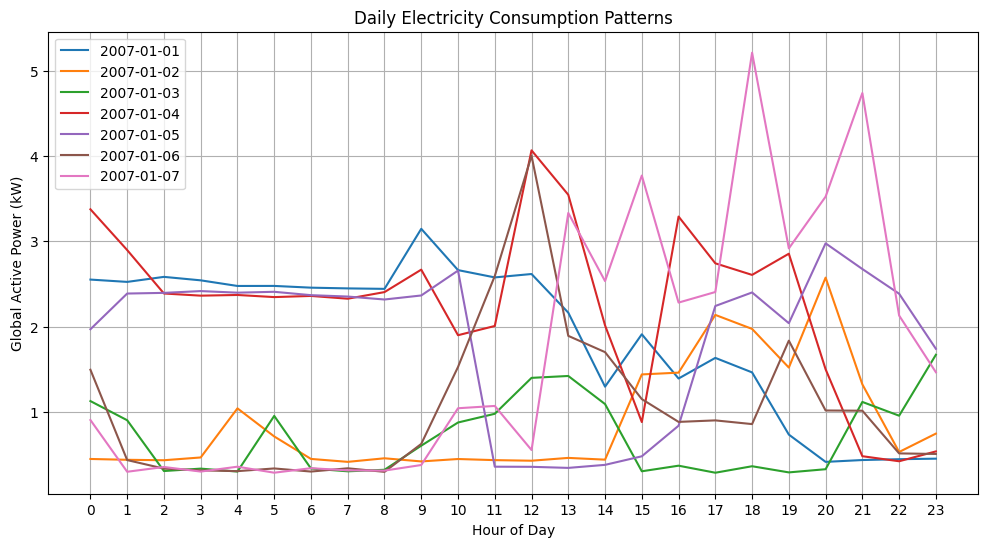

In [ ]:
# Fix index (important)
daily_matrix.index = daily_matrix.index.astype(int)
daily_matrix = daily_matrix.sort_index()

plt.figure(figsize=(12,6))
for col in daily_matrix.columns:
    plt.plot(daily_matrix.index, daily_matrix[col], label=str(col))

plt.title("Daily Electricity Consumption Patterns")
plt.xlabel("Hour of Day")
plt.ylabel("Global Active Power (kW)")
plt.xticks(range(24))
plt.grid(True)
plt.legend()   # same style as your weekday figure
plt.show()


In [ ]:
df['hour'] = df.index.hour
df['day'] = df.index.date

daily_matrix = df.pivot_table(
    index='hour',
    columns='day',
    values='Global_active_power',
    aggfunc='mean'
)
# Keep only days with 24 valid hourly values
daily_matrix = daily_matrix.dropna(axis=1)  # drop columns (days) with any NaN


In [ ]:


# Each row = a day, each column = hour 0–23
X = daily_matrix.T  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)


In [ ]:
cluster_map = dict(zip(X.index, cluster_labels))


In [ ]:
clustered_days = pd.DataFrame({
    'day': X.index,
    'cluster': cluster_labels
}).set_index('day')

daily_with_cluster = daily_matrix.T.join(clustered_days)

centroids = daily_with_cluster.groupby('cluster').mean().T  # 24 × cluster count
centroids


cluster,0,1,2
0,0.624992,0.540150,2.158421
1,0.486909,0.443039,2.008843
2,0.436191,0.390918,1.832843
3,0.396546,0.374015,1.665404
4,0.406780,0.376463,1.530995
5,0.420149,0.389126,1.481008
6,0.828759,0.678974,1.547753
7,1.730370,1.234183,1.805408
8,1.724285,1.165270,1.728129
9,1.573996,1.043547,1.749775


#### cluster 1: low consumption days
#### cluster 0: medium consumption days
#### cluser 2: high consumption days

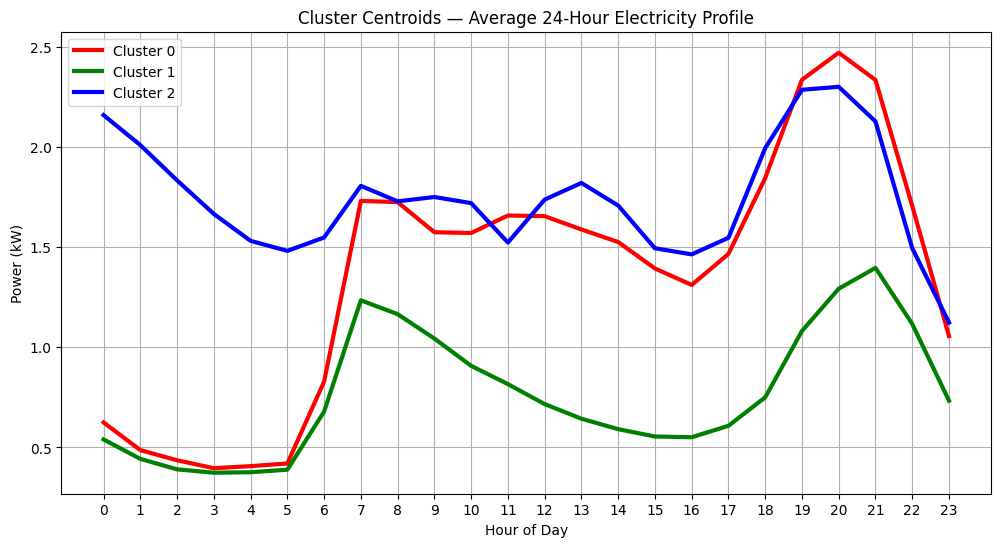

In [ ]:

plt.figure(figsize=(12,6))

colors = ['red', 'green', 'blue']

for c in centroids.columns:
    plt.plot(
        centroids.index,  # hour 0–23
        centroids[c],
        linewidth=3,
        color=colors[c],
        label=f'Cluster {c}'
    )

plt.title("Cluster Centroids — Average 24-Hour Electricity Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.show()


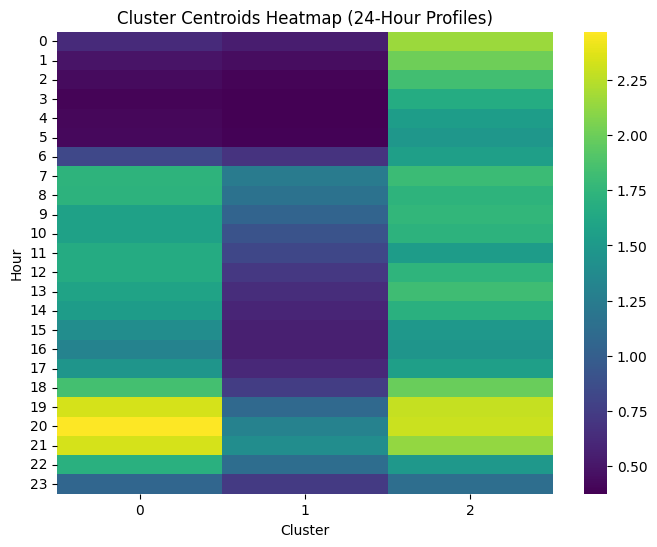

In [ ]:

plt.figure(figsize=(8,6))
sns.heatmap(
    centroids,      # 24 rows × k clusters
    cmap='viridis',
    annot=False
)
plt.title("Cluster Centroids Heatmap (24-Hour Profiles)")
plt.xlabel("Cluster")
plt.ylabel("Hour")
plt.yticks(rotation=0)
plt.show()


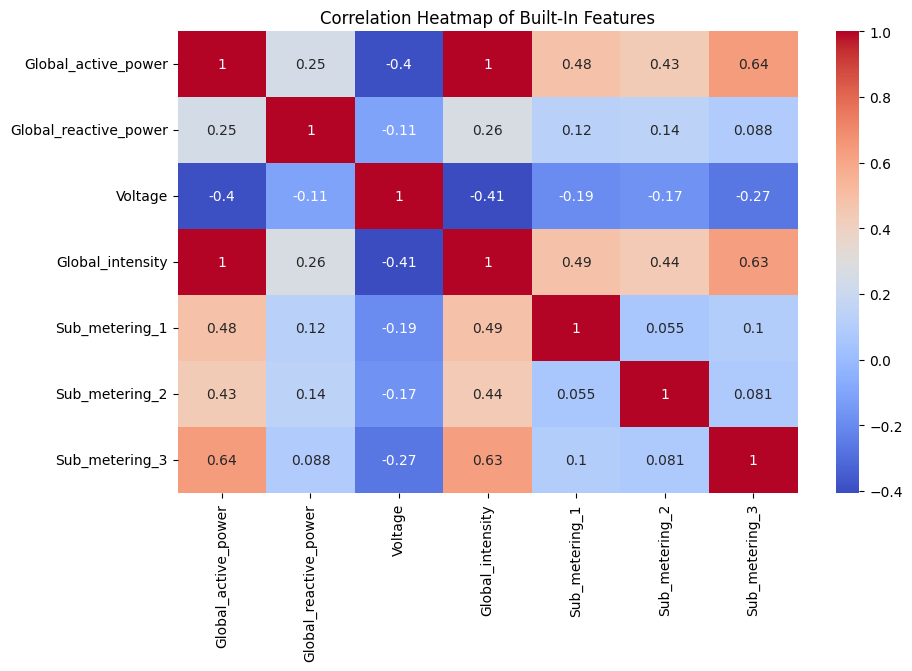

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Global_active_power','Global_reactive_power','Voltage',
                'Global_intensity','Sub_metering_1','Sub_metering_2',
                'Sub_metering_3']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Built-In Features")
plt.show()


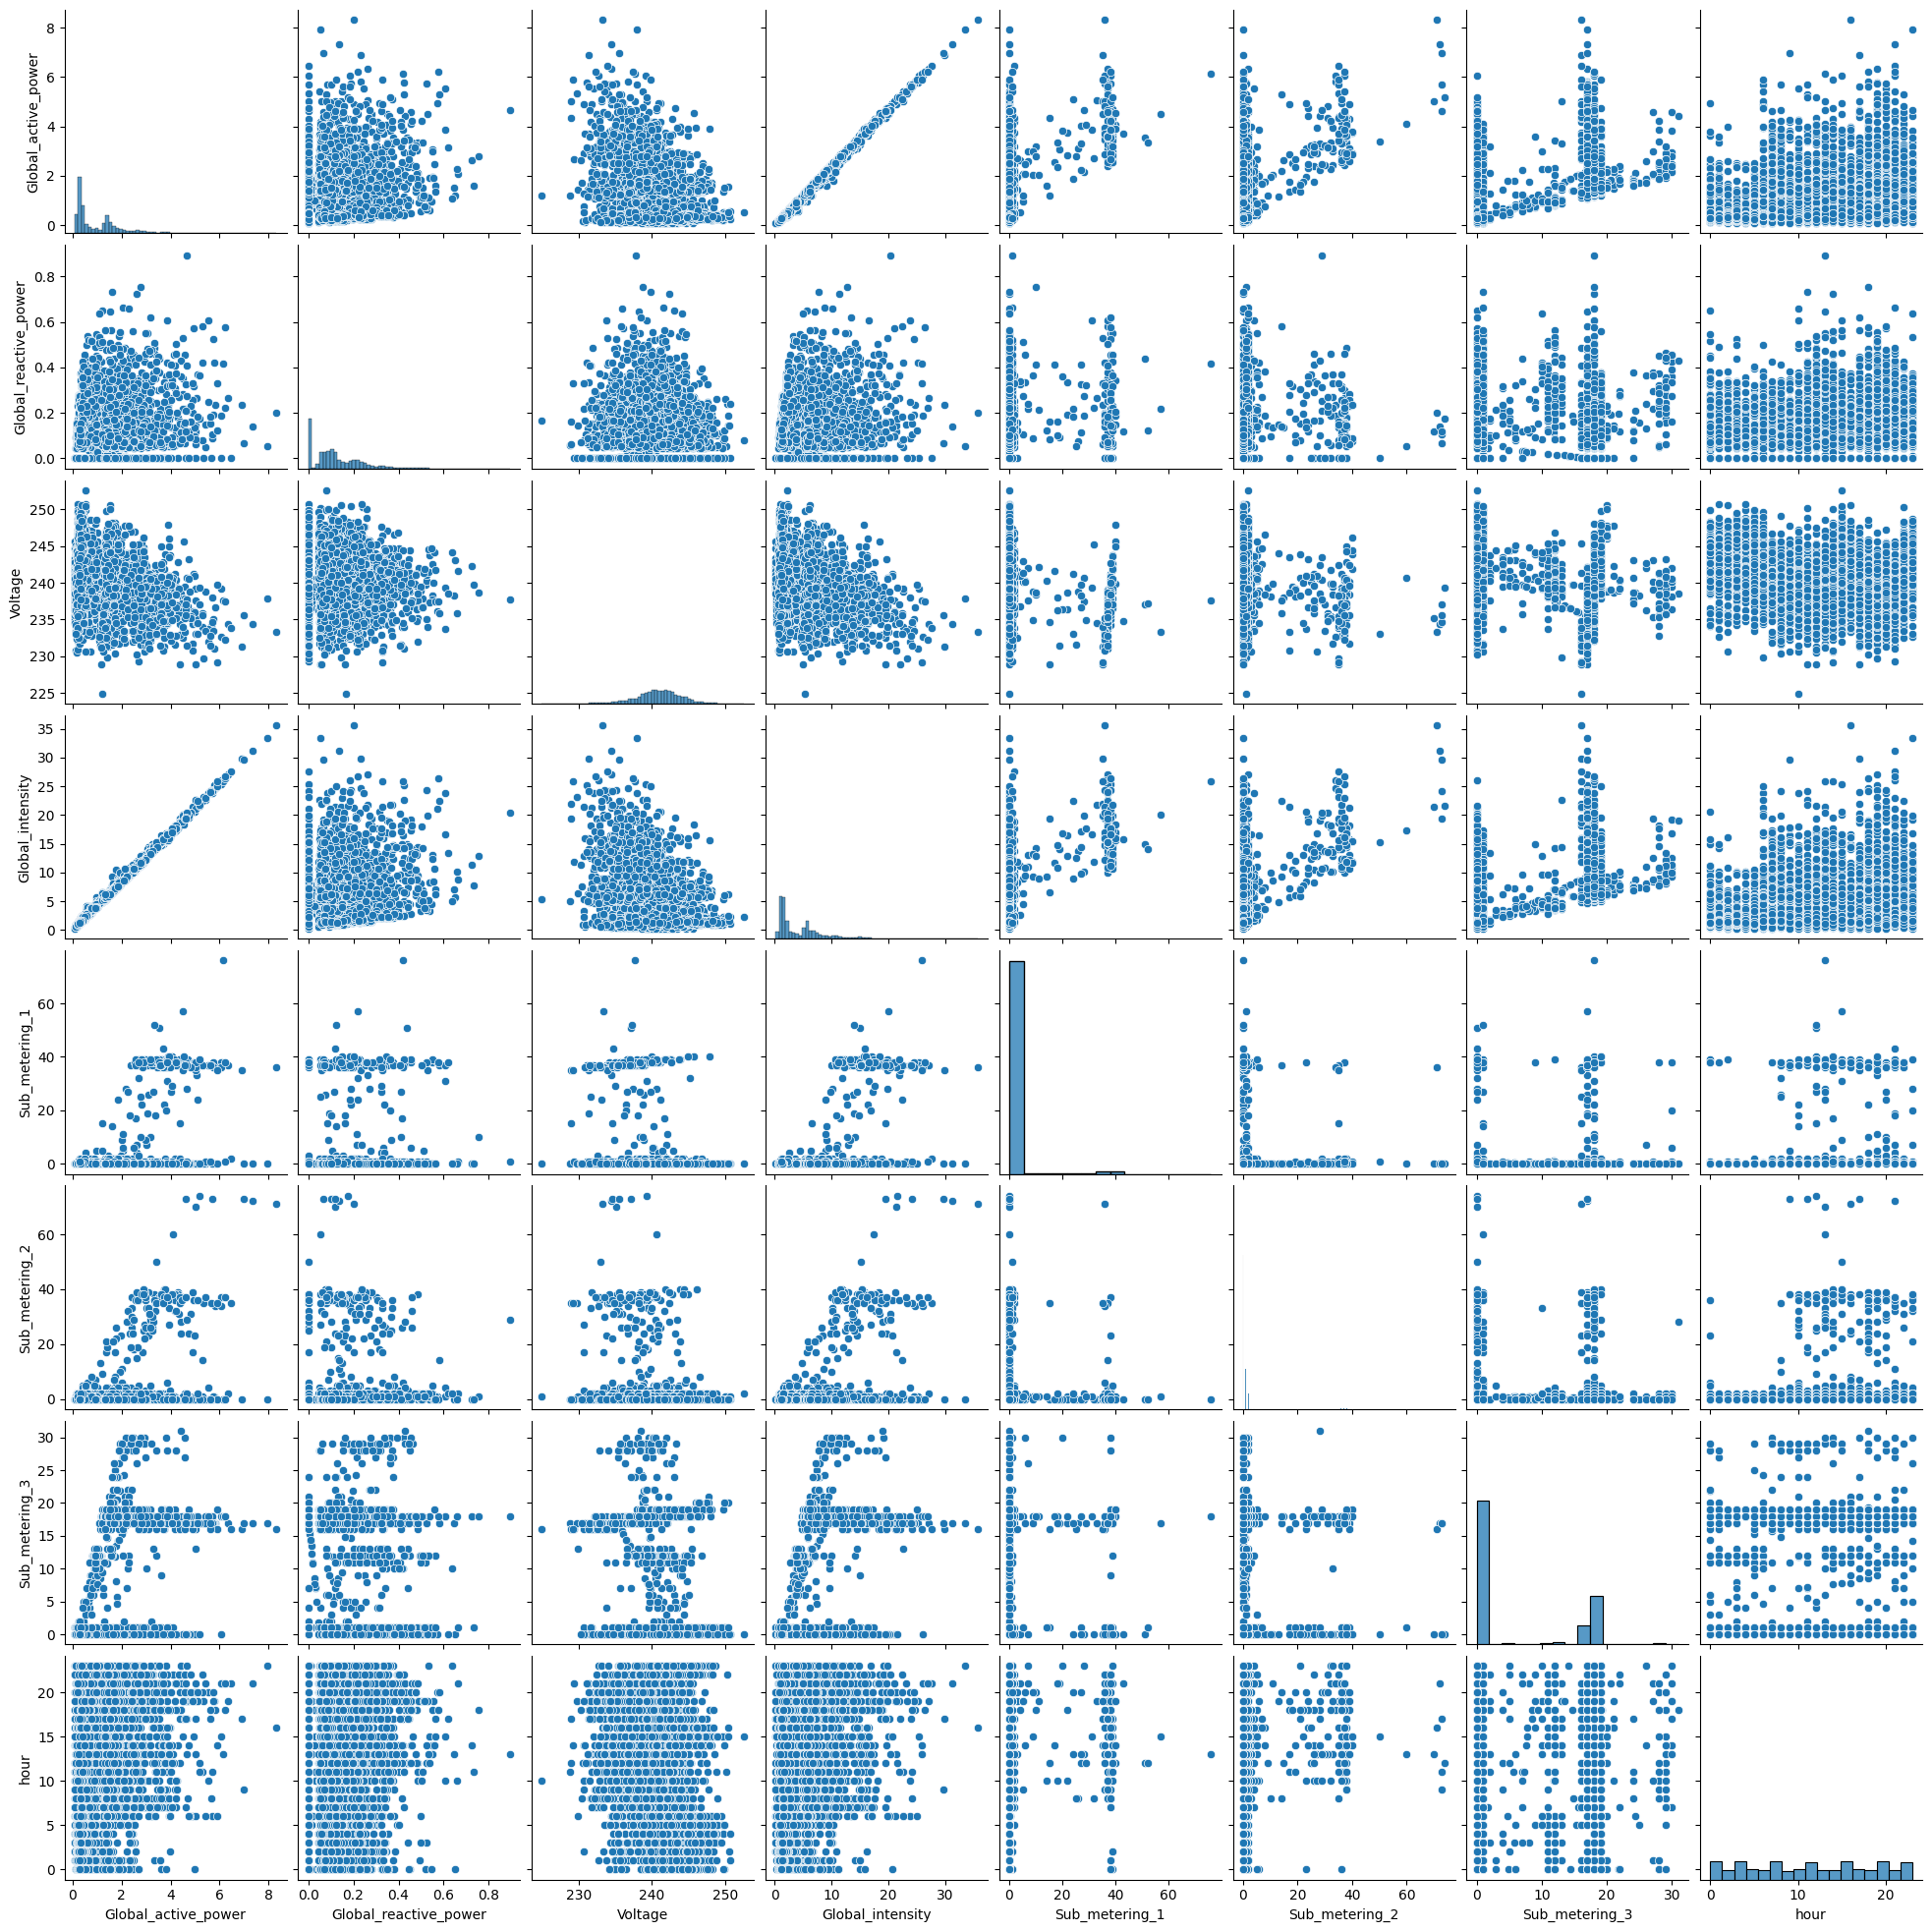

In [ ]:
sample_df = df.sample(5000) 
sns.pairplot(sample_df)
plt.show()


In [ ]:

# 1. LAG FEATURES

df['lag_1']   = df['Global_active_power'].shift(1)
df['lag_24']  = df['Global_active_power'].shift(24)
df['lag_48']  = df['Global_active_power'].shift(48)

# 2. ROLLING FEATURES
df['roll_3']   = df['Global_active_power'].rolling(3).mean()
df['roll_24']  = df['Global_active_power'].rolling(24).mean()
df['roll_168'] = df['Global_active_power'].rolling(168).mean()  # 7 days

# 3. TIME FEATURES
df['hour']       = df.index.hour
df['weekday']    = df.index.weekday
df['month']      = df.index.month
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# 4. CYCLIC ENCODING
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


# 5. SUB-METERING FEATURES
df['sub_total'] = (
    df['Sub_metering_1'] +
    df['Sub_metering_2'] +
    df['Sub_metering_3']
)

# Avoid division by zero
df['sub_total'] = df['sub_total'].replace(0, np.nan)

df['sub_ratio_1'] = df['Sub_metering_1'] / df['sub_total']
df['sub_ratio_2'] = df['Sub_metering_2'] / df['sub_total']
df['sub_ratio_3'] = df['Sub_metering_3'] / df['sub_total']

df[['sub_ratio_1','sub_ratio_2','sub_ratio_3']] = \
df[['sub_ratio_1','sub_ratio_2','sub_ratio_3']].fillna(0)

# 6. TARGET VARIABLE
df['target'] = df['Global_active_power'].shift(-1)


# REMOVE NaNs (from lag/roll/target)

df = df.dropna()

# 8. SELECT FEATURES

feature_cols = [
    'lag_1','lag_24','lag_48',
    'roll_3','roll_24','roll_168',
    'hour','weekday','month','is_weekend',
    'hour_sin','hour_cos',
    'Global_reactive_power',
    'Voltage','Global_intensity',
    'sub_total','sub_ratio_1','sub_ratio_2','sub_ratio_3'
]

X = df[feature_cols]
y = df['target']

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)


Final X shape: (1476144, 19)
Final y shape: (1476144,)


In [ ]:
n = len(df)

train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)




In [ ]:
WINDOW = 24

def create_sequences(X, y, window):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, WINDOW)
X_val_seq,   y_val_seq   = create_sequences(X_val_scaled,   y_val.values,   WINDOW)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test.values,  WINDOW)


In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 64)            21504     
                                                                 
 dropout (Dropout)           (None, 24, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 33953 (132.63 KB)
Trainable params: 33953 (132.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
es = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[es],
    shuffle=False
)


Epoch 1/50


16145/16145 [==============================] - 199s 12ms/step - loss: 0.2663 - mae: 0.2846 - val_loss: 0.1381 - val_mae: 0.2355
Epoch 2/50
16145/16145 [==============================] - 194s 12ms/step - loss: 0.1901 - mae: 0.2303 - val_loss: 0.1272 - val_mae: 0.2089
Epoch 3/50
16145/16145 [==============================] - 194s 12ms/step - loss: 0.1811 - mae: 0.2238 - val_loss: 0.1150 - val_mae: 0.1824
Epoch 4/50
16145/16145 [==============================] - 193s 12ms/step - loss: 0.1755 - mae: 0.2197 - val_loss: 0.1101 - val_mae: 0.1713
Epoch 5/50
16145/16145 [==============================] - 180s 11ms/step - loss: 0.1720 - mae: 0.2168 - val_loss: 0.1066 - val_mae: 0.1586
Epoch 6/50
16145/16145 [==============================] - 183s 11ms/step - loss: 0.1693 - mae: 0.2147 - val_loss: 0.1060 - val_mae: 0.1605
Epoch 7/50
16145/16145 [==============================] - 190s 12ms/step - loss: 0.1669 - mae: 0.2130 - val_loss: 0.1055 - val_mae: 0.1564
Epoch 8/50
16145/16145 [=

## scaled y value predictions ##



In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

# -----------------------
# 1. SCALE BOTH X AND y
# -----------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

# -----------------------
# 2. Create sequences (24 → 1)
# -----------------------
WINDOW = 24
def create_sequences(X, y, window):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW)
X_val_seq,   y_val_seq   = create_sequences(X_val_scaled,   y_val_scaled,   WINDOW)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_scaled,  WINDOW)

# -----------------------
# 3. LSTM Model (24→1)
# -----------------------
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# -----------------------
# 4. Train With Early Stopping
# -----------------------
es = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

# -----------------------
# 5. Scaled MSE
# -----------------------
pred_scaled = model.predict(X_test_seq)

mse_scaled = mean_squared_error(y_test_seq, pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)

print("\n--- Model Evaluation (Scaled) ---")
print(f"Test MSE: {mse_scaled:.4f}")
print(f"Test RMSE: {rmse_scaled:.4f}")

print("\n--- Model Parameters ---")
print(model.count_params())



Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 24, 64)            21504     
                                                                 
 dropout_6 (Dropout)         (None, 24, 64)            0         
                                                                 
 lstm_7 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_7 (Dropout)         (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 33953 (132.63 KB)
Trainable params: 33953 (132.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
1614

In [ ]:
# 5. Scaled MSE
# -----------------------
pred_scaled = model.predict(X_test_seq)

mse_scaled = mean_squared_error(y_test_seq, pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)

print("\n--- Model Evaluation (Scaled) ---")
print(f"Test MSE: {mse_scaled:.4f}")
print(f"Test RMSE: {rmse_scaled:.4f}")

print("\n--- Model Parameters ---")
print(model.count_params())


6919/6919 [==============================] - 23s 3ms/step

--- Model Evaluation (Scaled) ---
Test MSE: 0.0007
Test RMSE: 0.0258

--- Model Parameters ---
33953


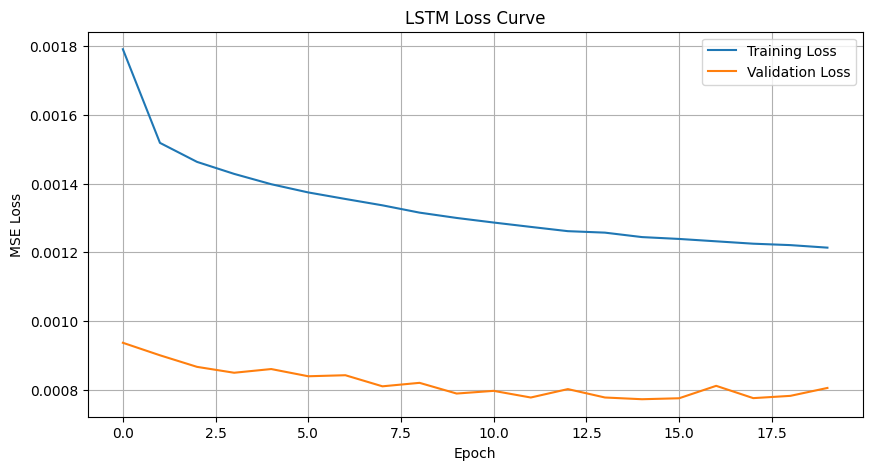

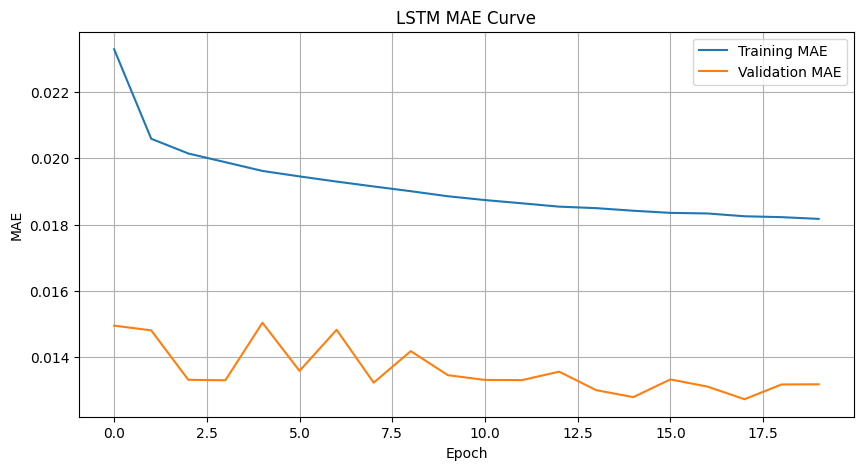

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("LSTM MAE Curve")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


In [38]:
lag_1_index = feature_cols.index('lag_1')

y_pred_baseline = X_test_seq[:, -1, lag_1_index]

print("Baseline MAE:", mean_absolute_error(y_test_seq, y_pred_baseline))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test_seq, y_pred_baseline)))


Baseline MAE: 0.9449021672472901
Baseline RMSE: 1.2418371863092854


In [39]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 64)            21504     
                                                                 
 dropout (Dropout)           (None, 24, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 33953 (132.63 KB)
Trainable params: 33953 (132.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [46]:
es = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=10,
    batch_size=64,
    callbacks=[es],
    shuffle=False
)


Epoch 1/10
16144/16144 [==============================] - 283s 18ms/step - loss: 0.1913 - mae: 0.2313 - val_loss: 0.1324 - val_mae: 0.2305
Epoch 2/10
16144/16144 [==============================] - 214s 13ms/step - loss: 0.1835 - mae: 0.2252 - val_loss: 0.1188 - val_mae: 0.1943
Epoch 3/10
16144/16144 [==============================] - 228s 14ms/step - loss: 0.1794 - mae: 0.2221 - val_loss: 0.1125 - val_mae: 0.1742
Epoch 4/10
16144/16144 [==============================] - 234s 14ms/step - loss: 0.1757 - mae: 0.2194 - val_loss: 0.1093 - val_mae: 0.1656
Epoch 5/10
16144/16144 [==============================] - 235s 15ms/step - loss: 0.1727 - mae: 0.2174 - val_loss: 0.1080 - val_mae: 0.1593
Epoch 6/10
16144/16144 [==============================] - 229s 14ms/step - loss: 0.1706 - mae: 0.2162 - val_loss: 0.1082 - val_mae: 0.1607
Epoch 7/10
16144/16144 [==============================] - 230s 14ms/step - loss: 0.1685 - mae: 0.2147 - val_loss: 0.1063 - val_mae: 0.1573
Epoch 8/10
16144/16144 [===

In [51]:
y_pred = model.predict(X_test_seq).flatten()
mae_lstm = mean_absolute_error(y_test_seq, y_pred)
print("LSTM MAE:", mean_absolute_error(y_test_seq, y_pred))
print("LSTM RMSE:", np.sqrt(mean_squared_error(y_test_seq, y_pred)))


6918/6918 [==============================] - 26s 4ms/step
LSTM MAE: 0.14681210008359427
LSTM RMSE: 0.293800922579928


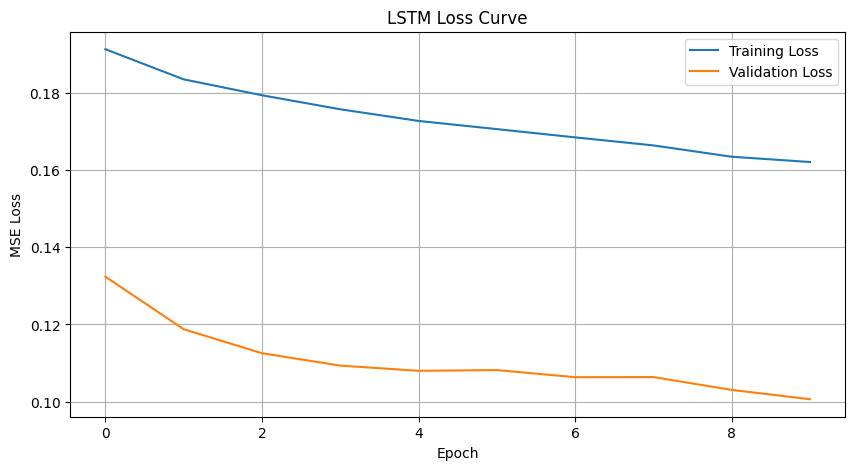

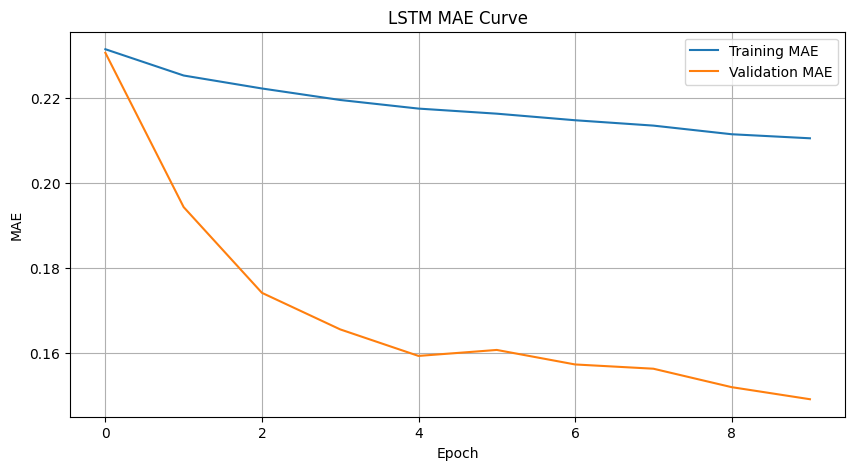

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("LSTM MAE Curve")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


6918/6918 [==============================] - 28s 4ms/step


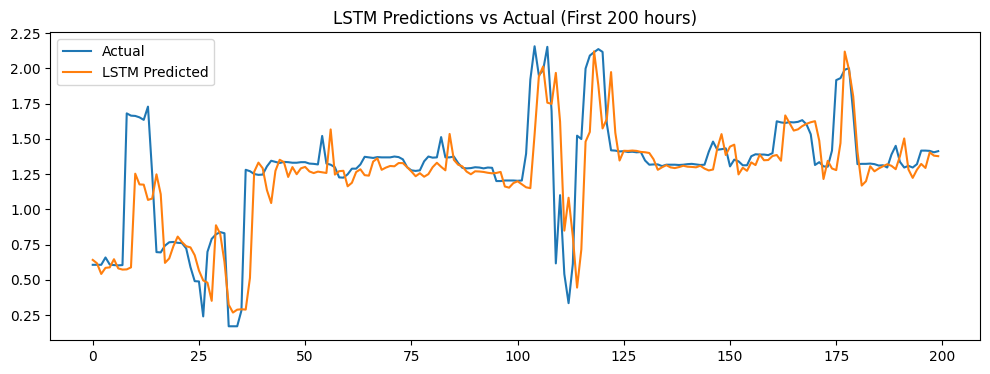

In [57]:
y_pred_lstm = model.predict(X_test_seq).flatten()
plt.figure(figsize=(12,4))
plt.plot(y_test_seq[:200], label='Actual')
plt.plot(y_pred_lstm[:200], label='LSTM Predicted')
plt.legend()
plt.title("LSTM Predictions vs Actual (First 200 hours)")
plt.show()


In [42]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

model_cnn_lstm = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(WINDOW, X_train_seq.shape[2])),
    MaxPooling1D(2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_cnn_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [44]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience=5, restore_best_weights=True)

history_cnn_lstm = model_cnn_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=10,
    batch_size=64,
    callbacks=[es],
    shuffle=False
)


Epoch 1/10
16144/16144 [==============================] - 245s 15ms/step - loss: 0.1953 - mae: 0.2396 - val_loss: 0.1198 - val_mae: 0.1872
Epoch 2/10
16144/16144 [==============================] - 149s 9ms/step - loss: 0.1883 - mae: 0.2335 - val_loss: 0.1154 - val_mae: 0.1742
Epoch 3/10
16144/16144 [==============================] - 161s 10ms/step - loss: 0.1844 - mae: 0.2303 - val_loss: 0.1162 - val_mae: 0.1751
Epoch 4/10
16144/16144 [==============================] - 173s 11ms/step - loss: 0.1814 - mae: 0.2279 - val_loss: 0.1136 - val_mae: 0.1702
Epoch 5/10
16144/16144 [==============================] - 195s 12ms/step - loss: 0.1792 - mae: 0.2257 - val_loss: 0.1129 - val_mae: 0.1680
Epoch 6/10
16144/16144 [==============================] - 152s 9ms/step - loss: 0.1770 - mae: 0.2241 - val_loss: 0.1138 - val_mae: 0.1694
Epoch 7/10
16144/16144 [==============================] - 159s 10ms/step - loss: 0.1753 - mae: 0.2228 - val_loss: 0.1113 - val_mae: 0.1657
Epoch 8/10
16144/16144 [=====

In [45]:
y_pred_cnn = model_cnn_lstm.predict(X_test_seq).flatten()
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_cnn = mean_absolute_error(y_test_seq, y_pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_test_seq, y_pred_cnn))

print("CNN-LSTM MAE:", mae_cnn)
print("CNN-LSTM RMSE:", rmse_cnn)


6918/6918 [==============================] - 18s 3ms/step
CNN-LSTM MAE: 0.15577539210003205
CNN-LSTM RMSE: 0.30174130570183477


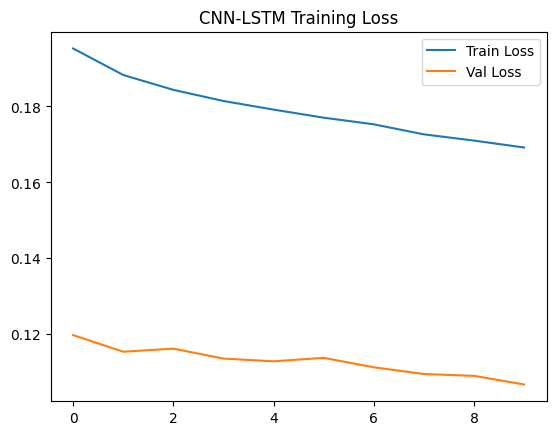

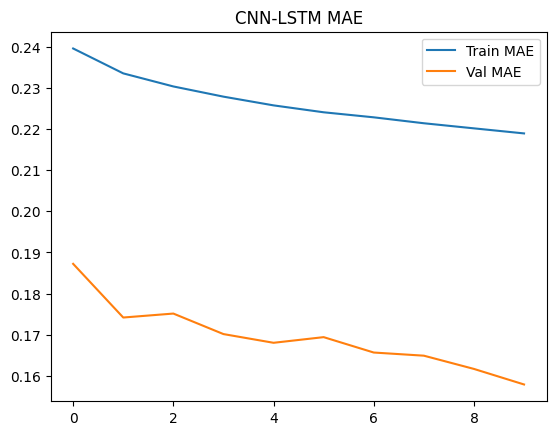

In [48]:
import matplotlib.pyplot as plt

plt.plot(history_cnn_lstm.history['loss'], label='Train Loss')
plt.plot(history_cnn_lstm.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("CNN-LSTM Training Loss")
plt.show()

plt.plot(history_cnn_lstm.history['mae'], label='Train MAE')
plt.plot(history_cnn_lstm.history['val_mae'], label='Val MAE')
plt.legend()
plt.title("CNN-LSTM MAE")
plt.show()


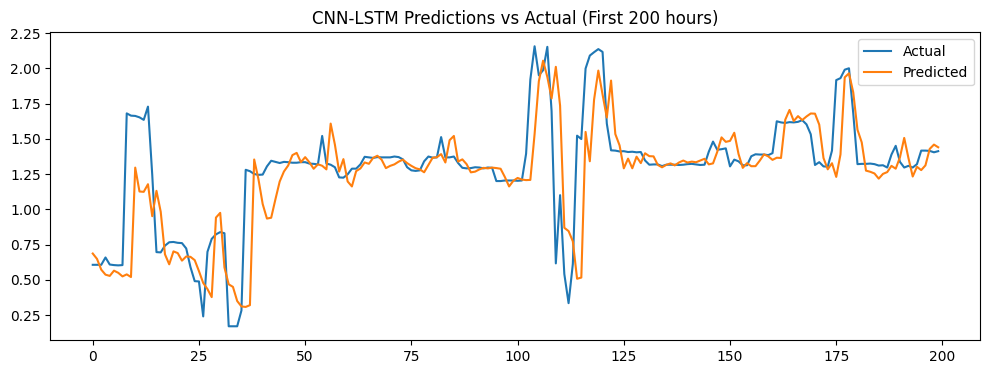

In [49]:
plt.figure(figsize=(12,4))
plt.plot(y_test_seq[:200], label='Actual')
plt.plot(y_pred_cnn[:200], label='Predicted')
plt.legend()
plt.title("CNN-LSTM Predictions vs Actual (First 200 hours)")
plt.show()


In [52]:
print("LSTM MAE:", mae_lstm)
print("CNN-LSTM MAE:", mae_cnn)

print("Improvement:", mae_lstm - mae_cnn)


LSTM MAE: 0.14681210008359427
CNN-LSTM MAE: 0.15577539210003205
Improvement: -0.00896329201643778


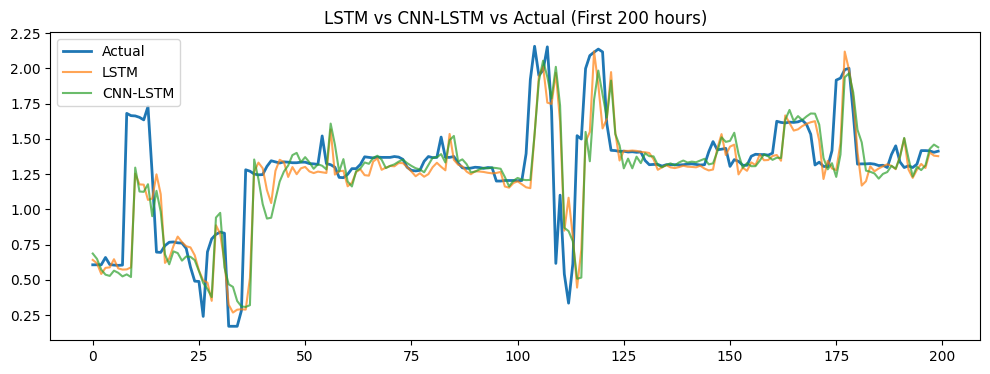

In [58]:
plt.figure(figsize=(12,4))
plt.plot(y_test_seq[:200], label='Actual', linewidth=2)
plt.plot(y_pred_lstm[:200], label='LSTM', alpha=0.7)
plt.plot(y_pred_cnn[:200], label='CNN-LSTM', alpha=0.7)
plt.legend()
plt.title("LSTM vs CNN-LSTM vs Actual (First 200 hours)")
plt.show()
